In [52]:
%pip install -r ../requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [61]:
ovgu_bbox = {
    "west": 11.639779,
    "east": 11.652739,
    "south": 52.137663,
    "north": 52.145538,
}

magdeburg_bbox = {
    "west": 11.5,
    "east": 12.0,
    "south": 52.0,
    "north": 52.3,
}

In [55]:
# Define temporal extent (date range for Sentinel-2 data)
start_date = "2024-05-01"
end_date = "2024-05-31"

# Load Sentinel-2 L2A data cube
cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=ovgu_bbox,
    temporal_extent=[start_date, end_date],
    bands=["B02", "B03", "B04", "B08"]  # Blue, Green, Red, NIR
)

# Optional: Apply cloud filtering using SCL band
# cube = cube.filter_bands(bands=["B02", "B03", "B04", "B08", "SCL"])

print("Data cube loaded successfully")
print(f"Spatial extent: {ovgu_bbox}")
print(f"Date range: {start_date} to {end_date}")
print(f"Selected bands: Blue, Green, Red, NIR")

Data cube loaded successfully
Spatial extent: {'west': 11.639779, 'east': 11.652739, 'south': 52.137663, 'north': 52.145538}
Date range: 2024-05-01 to 2024-05-31
Selected bands: Blue, Green, Red, NIR


In [56]:
# Execute the job and download the result
from pathlib import Path

# Create output directory if it doesn't exist
output_dir = Path("../data/sentinel2")
output_dir.mkdir(parents=True, exist_ok=True)

# Save the cube to a GeoTIFF file
output_file = output_dir / "magdeburg_sentinel2_20240501.tif"
print(f"Saving data to {output_file}...")

# Create a task and execute it
job = cube.save_result(format="GTiff", options={"compress": "deflate"})
# Run the batch job (do not try to download a single file when multiple assets exist)
job = job.execute_batch()

# Download all result assets produced by the job into the output directory
results = job.get_results()
results.download_files(target=str(output_dir))

print(f"Download complete!")
print(f"Saved files to: {output_dir}")

Saving data to ../data/sentinel2/magdeburg_sentinel2_20240501.tif...
0:00:00 Job 'j-2605182054024956a47a3c183e5ed0d6': send 'start'
0:00:30 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:00:35 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:00:42 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:00:50 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:01:00 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:01:13 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:01:28 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:01:47 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:02:11 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:02:41 Job 'j-2605182054024956a47a3c183e5ed0d6': queued (progress 0%)
0:03:19 Job 'j-2605182054024956a47a3c183e5ed0d6': finished (progress 100%)
Download complete!
Saved files to: ../data/sentinel2


File     : openEO_2024-05-03Z.tif
CRS      : EPSG:32632
Shape    : (92, 93)  (4 bands)
Dtype    : int16
Value range (Red band): 325 – 12000


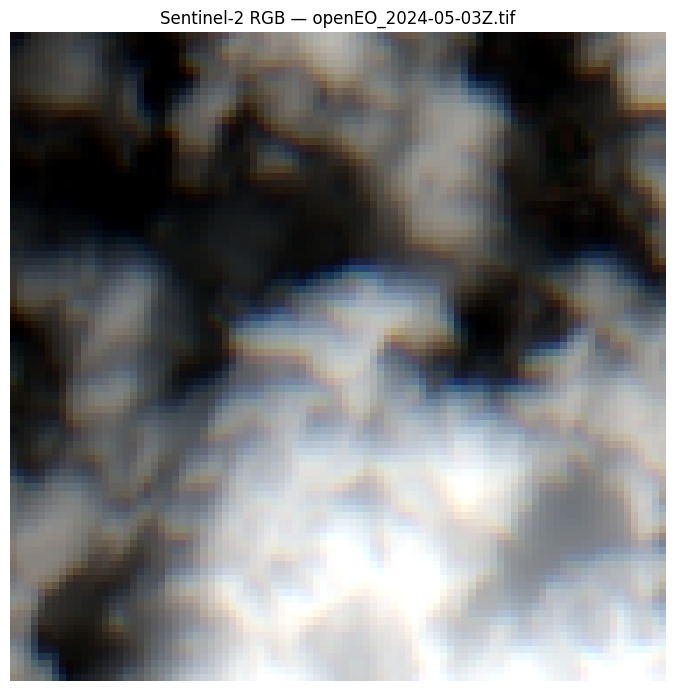

In [57]:
def percentile_stretch(band, p_low=2, p_high=98):
    """Normalize band to [0,1] using percentile clipping, ignoring zero/nodata pixels."""
    valid = band[band > 0]
    if valid.size == 0:
        return np.zeros_like(band, dtype=float)
    low, high = np.percentile(valid, [p_low, p_high])
    return np.clip((band.astype(float) - low) / (high - low + 1e-9), 0, 1)

import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

output_dir = Path("../data/sentinel2")
output_file = output_dir / "magdeburg_sentinel2_20240501.tif"

if not output_file.exists():
    tif_files = sorted(output_dir.glob("*.tif"))
    if tif_files:
        output_file = tif_files[0]

if output_file.exists():
    with rasterio.open(output_file) as src:
        print(f"File     : {output_file.name}")
        print(f"CRS      : {src.crs}")
        print(f"Shape    : {src.shape}  ({src.count} bands)")
        print(f"Dtype    : {src.dtypes[0]}")
        b04, b03, b02 = src.read(3), src.read(2), src.read(1)   # Red, Green, Blue
        print(f"Value range (Red band): {b04.min()} – {b04.max()}")

    rgb = np.dstack([percentile_stretch(b04),
                     percentile_stretch(b03),
                     percentile_stretch(b02)])
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(rgb)
    ax.set_title(f"Sentinel-2 RGB — {output_file.name}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("File not found.")


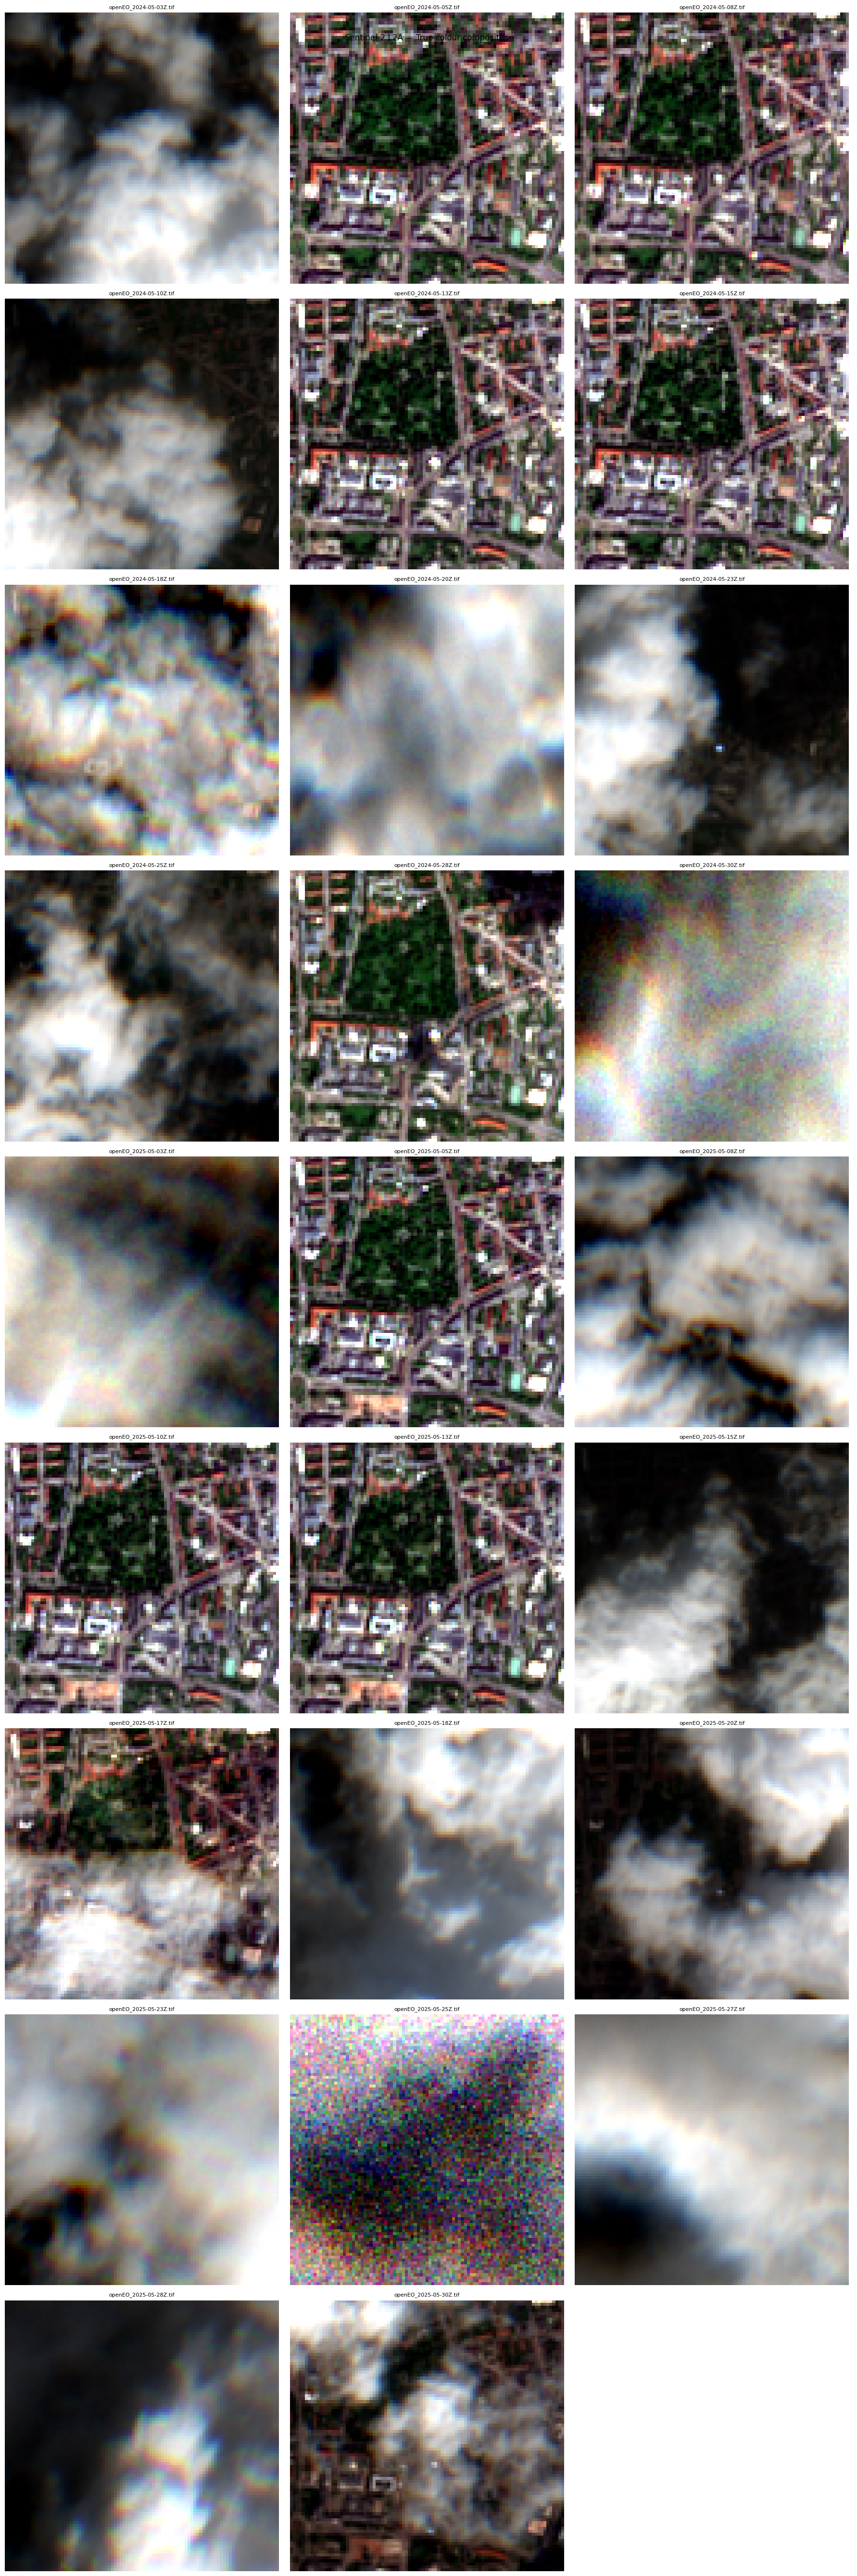

In [58]:
def percentile_stretch(band, p_low=2, p_high=98):
    """Normalize band to [0,1] using percentile clipping, ignoring zero/nodata pixels."""
    valid = band[band > 0]
    if valid.size == 0:
        return np.zeros_like(band, dtype=float)
    low, high = np.percentile(valid, [p_low, p_high])
    return np.clip((band.astype(float) - low) / (high - low + 1e-9), 0, 1)

from math import ceil

all_tif_files = sorted(output_dir.glob("*.tif"))

if not all_tif_files:
    print(f"No GeoTIFF files found in {output_dir}")
else:
    ncols = 3
    nrows = ceil(len(all_tif_files) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, tif_path in zip(axes, all_tif_files):
        with rasterio.open(tif_path) as src:
            b04, b03, b02 = src.read(3), src.read(2), src.read(1)

        rgb = np.dstack([percentile_stretch(b04),
                         percentile_stretch(b03),
                         percentile_stretch(b02)])
        ax.imshow(rgb)
        ax.set_title(tif_path.name, fontsize=8)
        ax.axis("off")

    for ax in axes[len(all_tif_files):]:
        ax.axis("off")

    plt.suptitle("Sentinel-2 L2A — True colour composites", fontsize=12)
    plt.tight_layout()
    plt.show()


## Higher-Resolution Orthophotos

Sachsen-Anhalt orthophoto service

https://www.lvermgeo.sachsen-anhalt.de/de/gdp-open-data.html

In [59]:
# Inspect the orthophoto WMS capabilities and list matching layers
import requests
import xml.etree.ElementTree as ET

wms_capabilities_url = "https://www.geodatenportal.sachsen-anhalt.de/wss/service/ST_LVermGeo_DOP_WMS_OpenData/guest?SERVICE=WMS&VERSION=1.3.0&REQUEST=GetCapabilities"
response = requests.get(wms_capabilities_url, timeout=30)
response.raise_for_status()

root = ET.fromstring(response.text)
namespace = {
    "wms": "http://www.opengis.net/wms",
}

layers = []
for layer in root.findall(".//wms:Layer", namespace):
    name_element = layer.find("wms:Name", namespace)
    title_element = layer.find("wms:Title", namespace)
    if name_element is not None and title_element is not None:
        layers.append((name_element.text, title_element.text))

orthophoto_layers = [item for item in layers if item[0] and ("DOP" in item[0] or "Orth" in item[1] or "DOP" in item[1])]

print(f"Found {len(orthophoto_layers)} orthophoto-related layers")
for name, title in orthophoto_layers[:20]:
    print(f"- {name}: {title}")

Found 2 orthophoto-related layers
- lsa_lvermgeo_dop20_2: Digitale Orthophotos
- lsa_lvermgeo_dop100_unbesch: DOP100


Requesting dop20_ovgu.png with BBOX=680650.1286411083,5779636.164493273,681504.8424704387,5780544.191040694
Saved ../data/orthophotos/dop20_ovgu.png (3413790 bytes)
Requesting dop20_magdeburg.png with BBOX=671613.2237577542,5763989.366599672,704548.5540451109,5798644.6756523205
Saved ../data/orthophotos/dop20_magdeburg.png (4229287 bytes)


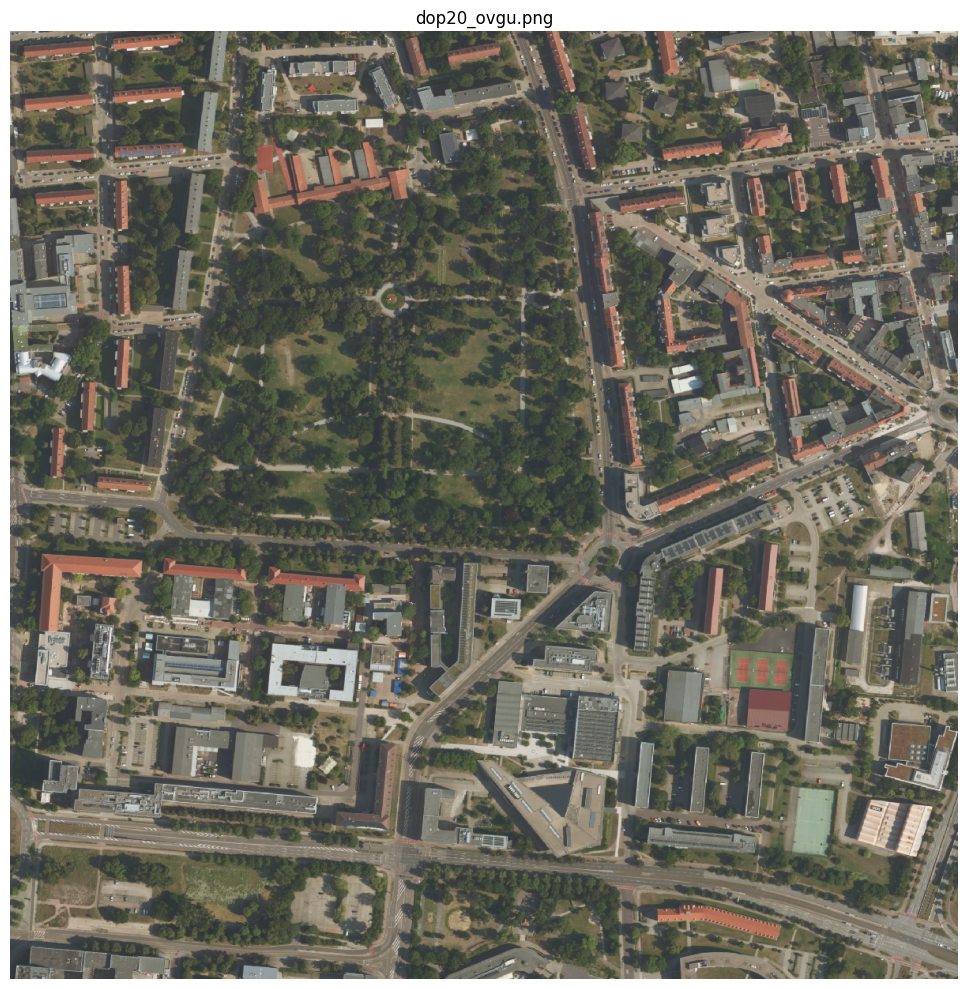

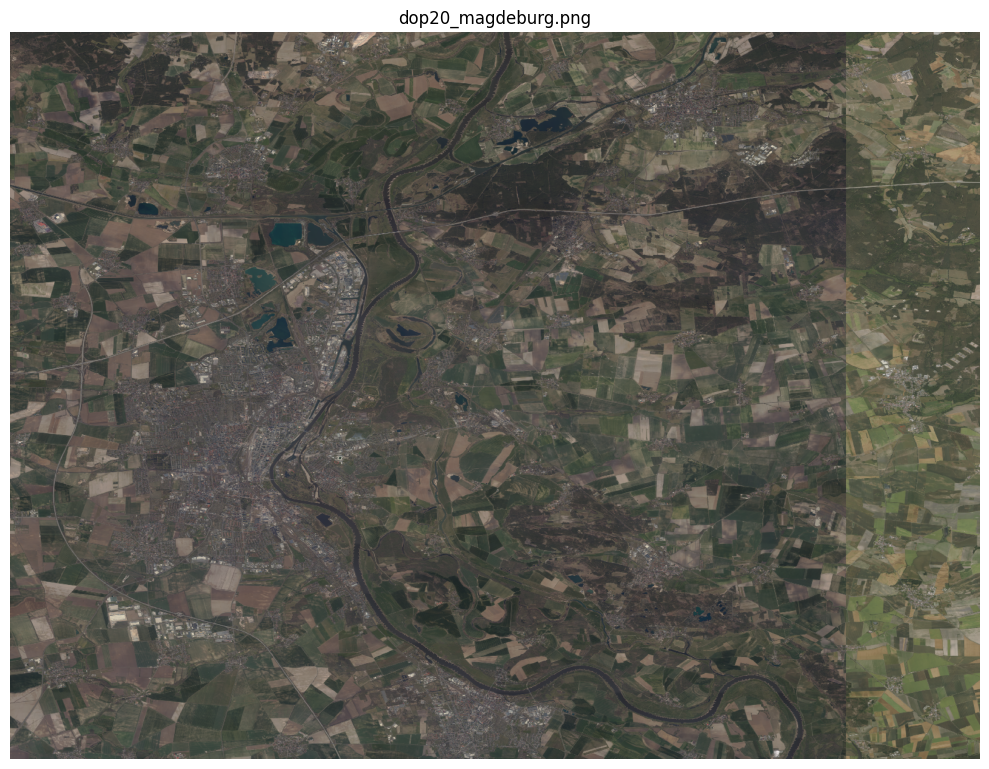

All images saved to: ../data/orthophotos


In [62]:
# Download and save orthophotos (DOP20) to ../data/orthophotos
from io import BytesIO
from pathlib import Path
import requests
import matplotlib.pyplot as plt
from PIL import Image
from pyproj import Transformer

output_dir = Path("../data/orthophotos")
output_dir.mkdir(parents=True, exist_ok=True)

wms_getmap_url = "https://www.geodatenportal.sachsen-anhalt.de/wss/service/ST_LVermGeo_DOP_WMS_OpenData/guest"
transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
requests_timeout = 60

def fetch_and_save(bbox, filename, width_px, height_px):
    min_x, min_y = transformer.transform(bbox["west"], bbox["south"])
    max_x, max_y = transformer.transform(bbox["east"], bbox["north"])
    params = {
        "SERVICE": "WMS",
        "VERSION": "1.3.0",
        "REQUEST": "GetMap",
        "LAYERS": "lsa_lvermgeo_dop20_2",
        "STYLES": "",
        "CRS": "EPSG:25832",
        "BBOX": f"{min_x},{min_y},{max_x},{max_y}",
        "WIDTH": width_px,
        "HEIGHT": height_px,
        "FORMAT": "image/png",
        "TRANSPARENT": "false",
    }
    print(f"Requesting {filename} with BBOX={params['BBOX']}")
    response = requests.get(wms_getmap_url, params=params, timeout=requests_timeout)
    response.raise_for_status()
    out_path = output_dir / filename
    out_path.write_bytes(response.content)
    print(f"Saved {out_path} ({out_path.stat().st_size} bytes)")
    return out_path

# Use the bbox variables defined earlier in the notebook
ovgu_path = fetch_and_save(ovgu_bbox, "dop20_ovgu.png", 1200, 1200)
magdeburg_path = fetch_and_save(magdeburg_bbox, "dop20_magdeburg.png", 1600, 1200)

# Plot each image separately
for img_path in [ovgu_path, magdeburg_path]:
    image = Image.open(img_path)
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    ax.set_title(img_path.name)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

print("All images saved to:", output_dir)